In [34]:
!pip install "fuzzywuzzy[speedup]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 558.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [python-levenshtein]evenshtein]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

# Load the CSV
df = pd.read_csv("./data/data.csv")

In [5]:
df.columns

Index(['drep_id', 'delegator_stake_address', 'delegation_epoch',
       'delegation_timestamp', 'transaction_hash', 'certificate_index_in_tx'],
      dtype='object')

In [6]:
df_sorted = df.sort_values(
    by=["delegator_stake_address", "delegation_epoch", "certificate_index_in_tx"]
).reset_index(drop=True)

In [7]:
# Group by delegation_epoch and drep_id, and count unique delegators
delegator_counts = (
    df_sorted.groupby(["delegation_epoch", "drep_id"])["delegator_stake_address"]
    .nunique()
    .reset_index(name="num_delegators")
)

print(delegator_counts)

       delegation_epoch                                            drep_id  \
0                   507  drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xj...   
1                   507  drep102j4x2aqqj06l88678r8pnml58jc0c8gqltseswyj...   
2                   507  drep106asgfntqf5snyw7glg3tk9a2gh7epcps7kf98j9m...   
3                   507  drep107e480v044a2rjjny8xg6xvjurpgrxkg75f5jnfa3...   
4                   507  drep109rd2sz08kvw089d4hw7zy2ygjs575rwh429ntn37...   
...                 ...                                                ...   
10048               574  drep1zl5s6j5p6wyw4ulw6zgsz7w8qjsgvyk5sa9n7f6q2...   
10049               574  drep1zpw2pt6ykazv4tcv7yax556my94hjny2vgcsuyws9...   
10050               574  drep1zzuasedw4v7ctfdfvrsmr6surqxh78fuakxvdnztu...   
10051               574                                drep_always_abstain   
10052               574                          drep_always_no_confidence   

       num_delegators  
0                   1  
1              

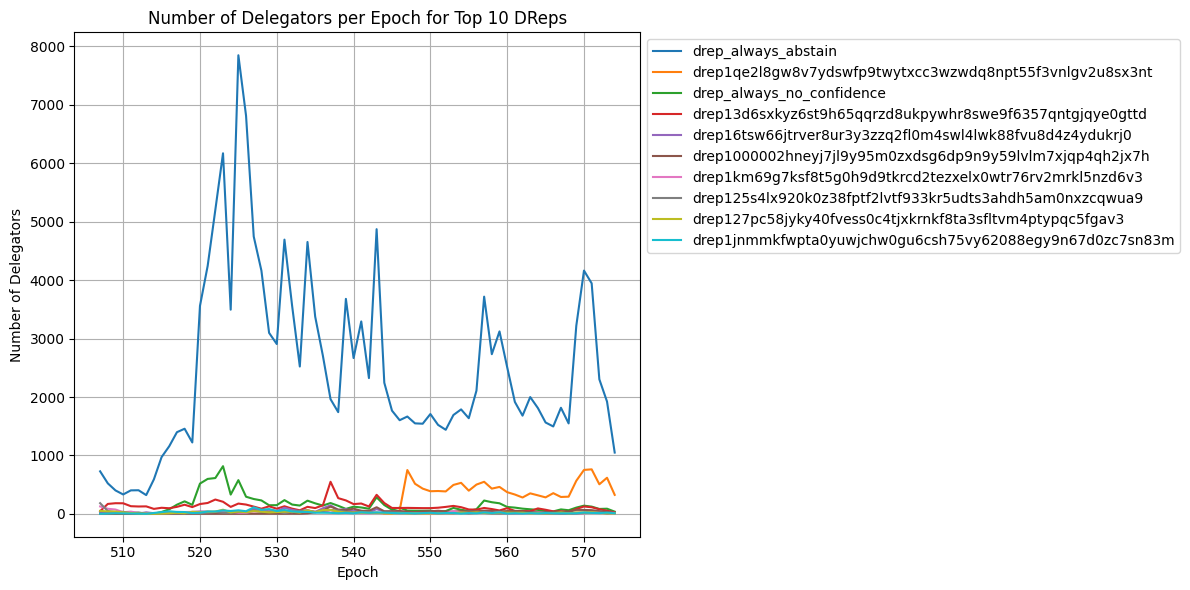

In [8]:
import matplotlib.pyplot as plt

# Step 1: Count unique delegators per epoch and DRep
delegator_counts = (
    df_sorted.groupby(["delegation_epoch", "drep_id"])["delegator_stake_address"]
    .nunique()
    .reset_index(name="num_delegators")
)

# Step 2: Find top 10 DReps by total delegators
top_dreps = (
    delegator_counts.groupby("drep_id")["num_delegators"]
    .sum()
    .nlargest(10)
    .index
)

# Step 3: Filter only top DReps
top_delegator_counts = delegator_counts[delegator_counts["drep_id"].isin(top_dreps)]

# Step 4: Plot
plt.figure(figsize=(12, 6))
for drep in top_dreps:
    drep_data = top_delegator_counts[top_delegator_counts["drep_id"] == drep]
    plt.plot(drep_data["delegation_epoch"], drep_data["num_delegators"], label=drep)

plt.xlabel("Epoch")
plt.ylabel("Number of Delegators")
plt.title("Number of Delegators per Epoch for Top 10 DReps")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.grid(True)
plt.show()


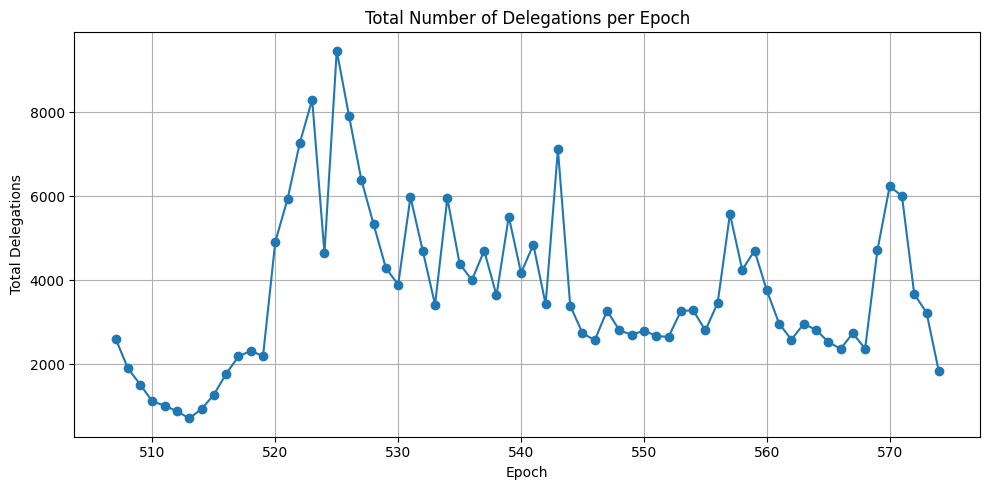

In [9]:
import matplotlib.pyplot as plt

# Step 1: Count total delegations per epoch
total_delegations = (
    df_sorted.groupby("delegation_epoch")
    .size()
    .reset_index(name="num_delegations")
)

# Step 2: Plot
plt.figure(figsize=(10, 5))
plt.plot(total_delegations["delegation_epoch"], total_delegations["num_delegations"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Delegations")
plt.title("Total Number of Delegations per Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()


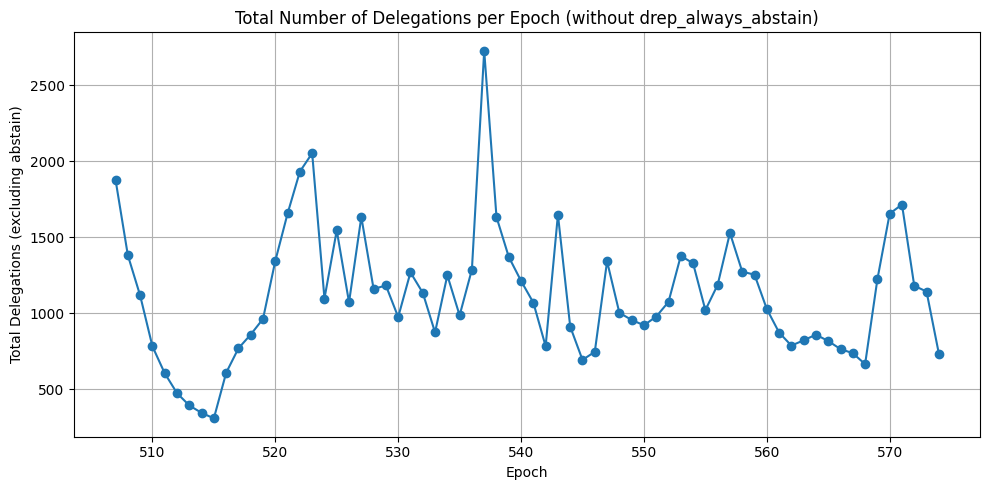

In [10]:
import matplotlib.pyplot as plt

# Step 1: Filter out 'drep_always_abstain'
df_filtered = df_sorted[df_sorted["drep_id"] != "drep_always_abstain"]

# Step 2: Count total delegations per epoch (excluding abstain)
total_delegations = (
    df_filtered.groupby("delegation_epoch")
    .size()
    .reset_index(name="num_delegations")
)

# Step 3: Plot
plt.figure(figsize=(10, 5))
plt.plot(total_delegations["delegation_epoch"], total_delegations["num_delegations"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Delegations (excluding abstain)")
plt.title("Total Number of Delegations per Epoch (without drep_always_abstain)")
plt.grid(True)
plt.tight_layout()
plt.show()


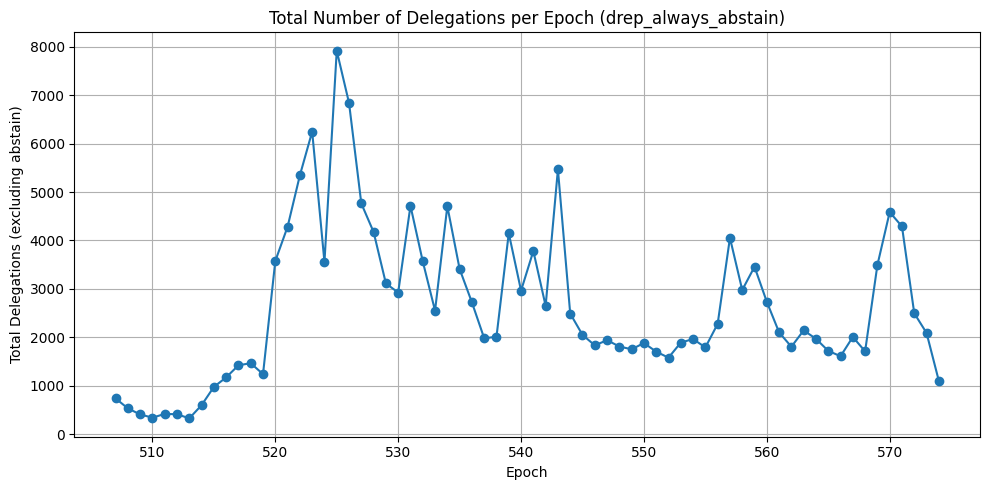

In [33]:

# Step 1: Filter out 'drep_always_abstain'
df_filtered = df_sorted[df_sorted["drep_id"] == "drep_always_abstain"]

# Step 2: Count total delegations per epoch (excluding abstain)
total_delegations = (
    df_filtered.groupby("delegation_epoch")
    .size()
    .reset_index(name="num_delegations")
)

# Step 3: Plot
plt.figure(figsize=(10, 5))
plt.plot(total_delegations["delegation_epoch"], total_delegations["num_delegations"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Delegations (excluding abstain)")
plt.title("Total Number of Delegations per Epoch (drep_always_abstain)")
plt.grid(True)
plt.tight_layout()
plt.show()

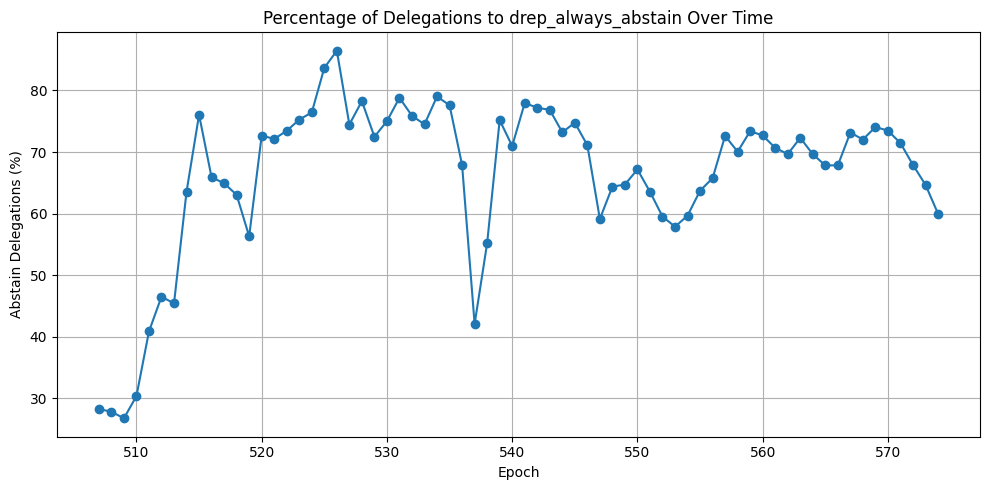

In [11]:
import matplotlib.pyplot as plt

# Step 1: Count total delegations per epoch
total_delegations = (
    df_sorted.groupby("delegation_epoch")
    .size()
    .reset_index(name="total_delegations")
)

# Step 2: Count abstain delegations per epoch
abstain_delegations = (
    df_sorted[df_sorted["drep_id"] == "drep_always_abstain"]
    .groupby("delegation_epoch")
    .size()
    .reset_index(name="abstain_delegations")
)

# Step 3: Merge both
merged = total_delegations.merge(abstain_delegations, on="delegation_epoch", how="left")
merged["abstain_delegations"] = merged["abstain_delegations"].fillna(0)

# Step 4: Calculate percentage
merged["abstain_percent"] = 100 * merged["abstain_delegations"] / merged["total_delegations"]

# Step 5: Plot
plt.figure(figsize=(10, 5))
plt.plot(merged["delegation_epoch"], merged["abstain_percent"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Abstain Delegations (%)")
plt.title("Percentage of Delegations to drep_always_abstain Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# Step 1: Sort by delegator and timestamp (if not already done)
df_sorted = df.sort_values(by=["delegator_stake_address", "delegation_timestamp"])

# Step 2: Add delegation index per delegator
df_sorted["delegation_index"] = df_sorted.groupby("delegator_stake_address").cumcount()

df_sorted.head()


,drep_id,delegator_stake_address,delegation_epoch,delegation_timestamp,transaction_hash,certificate_index_in_tx,delegation_index
189788,drep_always_abstain,stake17809f8t6jynfss0v3hhsh8myw4wgac5apfpz5ry7...,526,2024-12-07 15:51:32,binary data,0,0
28282,drep_always_abstain,stake1782gvfczrwx2mgw65cw2zrpxj52nd3v27cn5s88p...,567,2025-07-03 13:41:32,binary data,0,0
104663,drep_always_abstain,stake1784aqmh0clyxnw8x0wj4ygch954ttqhzfty9m56m...,543,2025-03-05 05:04:44,binary data,2,0
27739,drep_always_abstain,stake1785crwlg86smvmyut02n8wu9ttxt8hzhnhc39vxh...,568,2025-07-04 14:58:52,binary data,0,0
84696,drep_always_abstain,stake178a7thfltghxnut34yzk29n7e5n9mh0cpddz22ft...,550,2025-04-07 20:37:54,binary data,0,0


In [13]:
import pandas as pd

# Ensure delegation_timestamp is datetime
df_sorted['delegation_timestamp'] = pd.to_datetime(df_sorted['delegation_timestamp'])

# Step 1: Filter delegators with more than one delegation
delegation_counts = df_sorted['delegator_stake_address'].value_counts()
delegators_multi = delegation_counts[delegation_counts > 1].index

df_multi = df_sorted[df_sorted['delegator_stake_address'].isin(delegators_multi)]

# Step 2: Calculate average duration per delegator
def avg_duration_between_delegations(group):
    group = group.sort_values('delegation_timestamp')
    diffs = group['delegation_timestamp'].diff().dropna()
    return diffs.mean()

avg_durations = df_multi.groupby('delegator_stake_address').apply(avg_duration_between_delegations)

# Convert to days
avg_durations_days = avg_durations.dt.total_seconds() / (24 * 3600)

print(avg_durations_days.head())

# Overall average duration in days
overall_avg_duration_days = avg_durations_days.mean()
print(f"Overall average duration between delegations: {overall_avg_duration_days:.2f} days")


delegator_stake_address
stake1792qkmphmgxwu2fwv0mqscwnt6j0yvvxm9yxf02rse5pm5gszuy0n     9.880249
stake17974q569qp3tewqkd5a8kr8rpeygse5m2wwyfc3l83ht4wsftjhua    77.930139
stake179jnva8lp5gtgzpcnc8aef0en7gvzxt9jngp838g60hdezqcjuu4l    79.446516
stake179myrdadvmvx93xjmvyxsh2a0vy5up7qpwj20ax8ze02l5qpwa96l    38.683935
stake17x67r45qq9k77qn5xlgl43lmtpf9nv2904tn4232nndgsngyddr5x    85.410382
dtype: float64
Overall average duration between delegations: 49.22 days


/var/folders/vb/cd5tlbwj1gg4b3zk4dtfg1th0000gq/T/ipykernel_22619/1572142761.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_durations = df_multi.groupby('delegator_stake_address').apply(avg_duration_between_delegations)


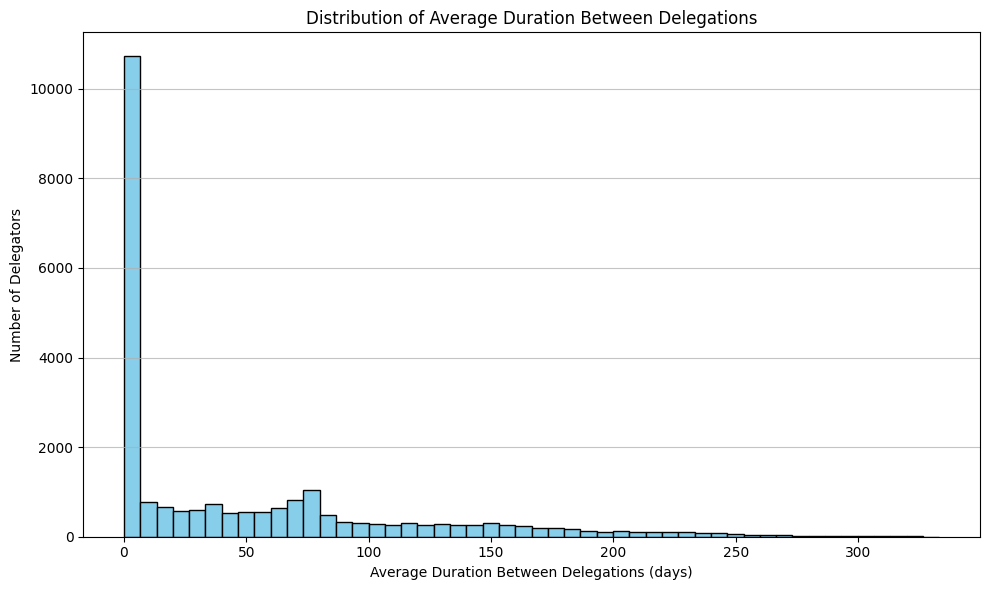

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(avg_durations_days.dropna(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Average Duration Between Delegations (days)")
plt.ylabel("Number of Delegators")
plt.title("Distribution of Average Duration Between Delegations")
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


In [15]:
less_than_10 = (avg_durations_days < 10).sum()
less_than_5 = (avg_durations_days < 5).sum()
less_than_2 = (avg_durations_days < 2).sum()

print(f"Number of delegators with avg duration < 10 days: {less_than_10}")
print(f"Number of delegators with avg duration < 5 days: {less_than_5}")
print(f"Number of delegators with avg duration < 2 days: {less_than_2}")


Number of delegators with avg duration < 10 days: 11142
Number of delegators with avg duration < 5 days: 10435
Number of delegators with avg duration < 2 days: 9825


In [16]:
# Step 1: Filter delegators with avg duration < 1 day
fast_delegators = avg_durations_days[avg_durations_days < 1].index

# Step 2: Filter df_sorted for those delegators
fast_delegations = df_sorted[df_sorted["delegator_stake_address"].isin(fast_delegators)]

# Step 3: Print or display
for delegator, group in fast_delegations.groupby("delegator_stake_address"):
    print(f"Delegator: {delegator}")
    print(group[["delegation_timestamp", "drep_id"]].sort_values("delegation_timestamp"))
    print("-" * 40)


Delegator: stake17x6xpmlx5pzk56njll29dca2vrnwkzkmtej3xrd3vqar0nqdmjlmz
      delegation_timestamp                                            drep_id
76413  2025-04-22 22:54:50                                drep_always_abstain
76406  2025-04-22 23:06:21  drep16yrdjg5my5mnfscnzfekjuawz609sqqdu8w7c4jth...
----------------------------------------
Delegator: stake17ykk9tlz6xaxel92uyk6rz4mfud7zkqg9ftwkgdk0rgvf4sf76cpf
      delegation_timestamp                                            drep_id
25468  2025-07-09 09:09:09                                drep_always_abstain
25461  2025-07-09 09:18:17  drep1m4zmrfswvf0e2xu29f28mm4mn2n289w7zdxlaq5gj...
----------------------------------------
Delegator: stake1u800esk5sq62ledyydn2etwk590mywzrgryydneq4mg3vagzxaza9
      delegation_timestamp                                            drep_id
16875  2025-07-17 15:46:28  drep1hz3af6wgav29ue9e8tdlgr2kd4gpfned63rupkt9z...
16765  2025-07-17 17:38:55                                drep_always_abstain
---

In [17]:
# Step 1: Compare each delegation with the previous one for the same stake address
df_sorted['prev_drep'] = df_sorted.groupby('delegator_stake_address')['drep_id'].shift()

# Step 2: Find where consecutive delegations are to the same DRep
same_drep_consecutive = df_sorted['drep_id'] == df_sorted['prev_drep']

# Step 3: Count how many stake addresses have at least one such case
stakes_with_repeats = df_sorted.loc[same_drep_consecutive, 'delegator_stake_address'].nunique()

# Step 4: Also count total occurrences if needed
total_repeat_occurrences = same_drep_consecutive.sum()

print(f"Number of 'stakes_with_repeats' same DRep: {stakes_with_repeats}")
print(f"Total number of repeat same DRep delegations: {total_repeat_occurrences}")


Number of 'stakes_with_repeats' same DRep: 12046
Total number of repeat same DRep delegations: 18214


In [18]:
# Step 1: Identify consecutive same-DRep delegations for each stake address
df_sorted['prev_drep'] = df_sorted.groupby('delegator_stake_address')['drep_id'].shift()

# Step 2: Keep only rows where DRep changes (or it's the first delegation for that stake)
df_no_repeats = df_sorted[df_sorted['drep_id'] != df_sorted['prev_drep']].copy()

# Step 3: Drop helper column
df_no_repeats.drop(columns='prev_drep', inplace=True)

# Optional: Reset index
df_no_repeats.reset_index(drop=True, inplace=True)

print(f"Original count: {len(df_sorted)}, After removing repeats: {len(df_no_repeats)}")


Original count: 254698, After removing repeats: 236484


/var/folders/vb/cd5tlbwj1gg4b3zk4dtfg1th0000gq/T/ipykernel_22619/4037660067.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_durations = df_multi.groupby('delegator_stake_address').apply(avg_duration)


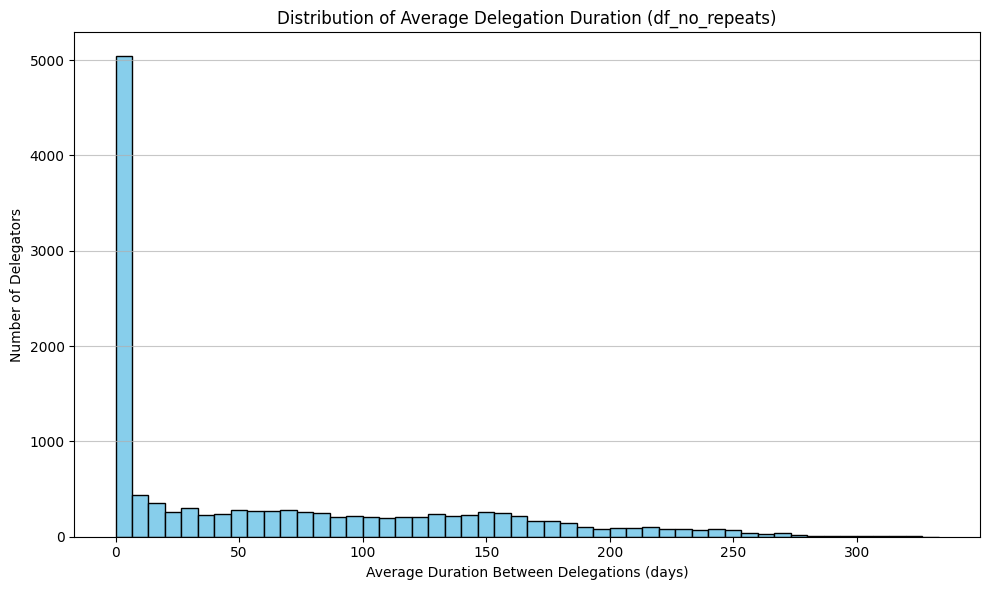

Overall average duration: 64.14 days
Overall median duration: 31.22 days


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure timestamp is datetime
df_no_repeats['delegation_timestamp'] = pd.to_datetime(df_no_repeats['delegation_timestamp'])

# Step 1: Keep only delegators with more than 1 delegation
counts = df_no_repeats['delegator_stake_address'].value_counts()
multi_delegators = counts[counts > 1].index
df_multi = df_no_repeats[df_no_repeats['delegator_stake_address'].isin(multi_delegators)]

# Step 2: Compute avg duration per delegator
def avg_duration(group):
    group = group.sort_values('delegation_timestamp')
    return group['delegation_timestamp'].diff().dropna().mean()

avg_durations = df_multi.groupby('delegator_stake_address').apply(avg_duration)
avg_durations_days = avg_durations.dt.total_seconds() / (24 * 3600)

# Step 3: Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(avg_durations_days.dropna(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Average Duration Between Delegations (days)")
plt.ylabel("Number of Delegators")
plt.title("Distribution of Average Delegation Duration (df_no_repeats)")
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

#Print overall average
print(f"Overall average duration: {avg_durations_days.mean():.2f} days")
#Print median
print(f"Overall median duration: {avg_durations_days.median():.2f} days")



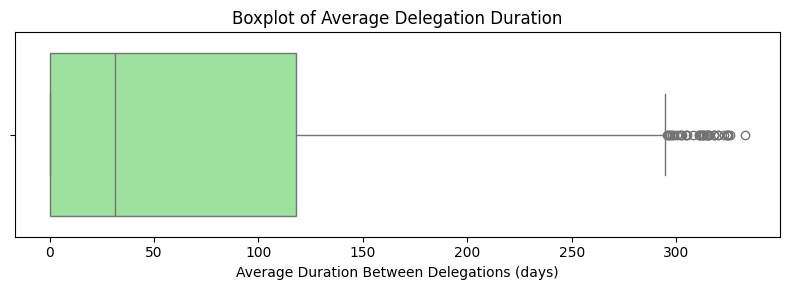

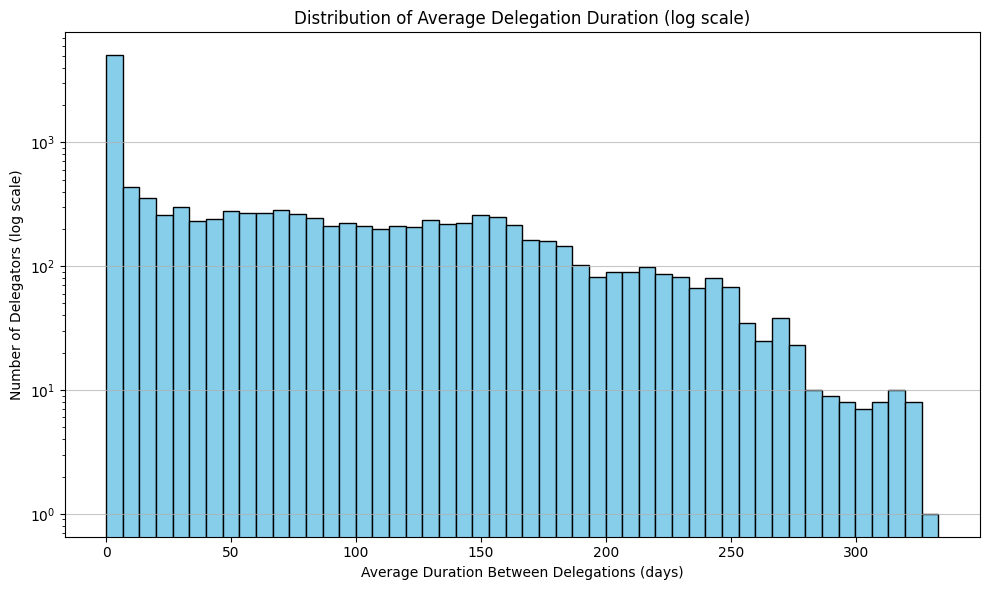

In [20]:
import seaborn as sns

plt.figure(figsize=(8, 3))
sns.boxplot(x=avg_durations_days.dropna(), color='lightgreen')
plt.xlabel("Average Duration Between Delegations (days)")
plt.title("Boxplot of Average Delegation Duration")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(avg_durations_days.dropna(), bins=50, color='skyblue', edgecolor='black', log=True)
plt.xlabel("Average Duration Between Delegations (days)")
plt.ylabel("Number of Delegators (log scale)")
plt.title("Distribution of Average Delegation Duration (log scale)")
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()



drep_id
1     208160
2      11415
3       1004
4        144
5         40
6         11
7          4
8          2
9          2
12         1
18         1
Name: count, dtype: int64 236484


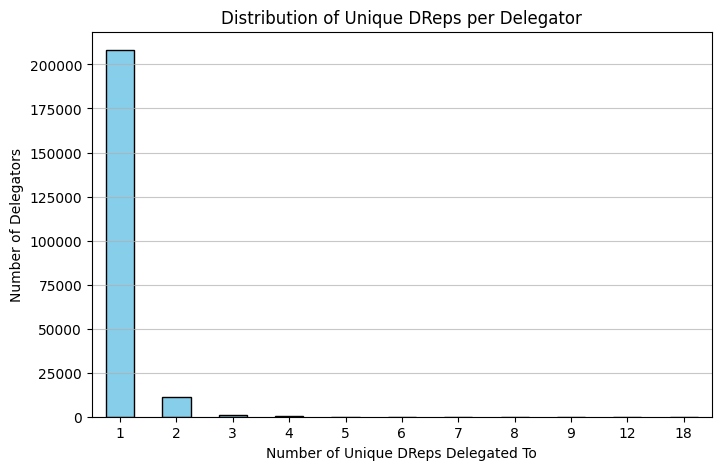

In [21]:
# Count unique DReps per delegator
unique_drep_counts = df_no_repeats.groupby('delegator_stake_address')['drep_id'].nunique()

# Count how many delegators fall into each bucket (1 unique, 2 unique, ...)
count_distribution = unique_drep_counts.value_counts().sort_index()

print(count_distribution, len(df_no_repeats))

# Optional: plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
count_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel("Number of Unique DReps Delegated To")
plt.ylabel("Number of Delegators")
plt.title("Distribution of Unique DReps per Delegator")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)
plt.show()


/var/folders/vb/cd5tlbwj1gg4b3zk4dtfg1th0000gq/T/ipykernel_22619/1055502972.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  non_consec_drep_counts = df_no_repeats.groupby('delegator_stake_address').apply(count_non_consecutive_dreps)


1     208160
2      10761
3       1369
4        286
5        118
6         33
7         15
8          7
9          7
10         5
11         4
12         5
14         2
15         1
16         1
19         1
21         2
22         1
23         2
31         1
36         1
42         1
88         1
Name: count, dtype: int64


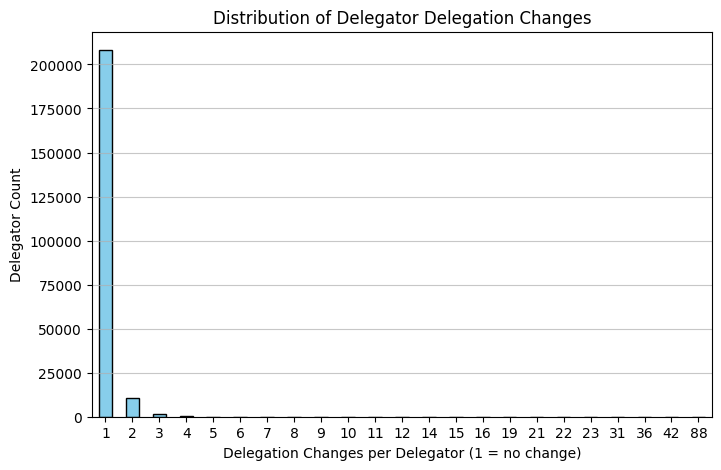

In [22]:
# For each delegator, get their drep_id sequence sorted by time
def count_non_consecutive_dreps(group):
    drep_seq = group.sort_values('delegation_timestamp')['drep_id'].tolist()
    # Count unique DReps ignoring consecutive repeats
    count = 1  # Always count the first delegation
    for i in range(1, len(drep_seq)):
        if drep_seq[i] != drep_seq[i-1]:
            count += 1
    return count

# Apply per delegator
non_consec_drep_counts = df_no_repeats.groupby('delegator_stake_address').apply(count_non_consecutive_dreps)

# Count how many delegators fall into each bucket
count_distribution = non_consec_drep_counts.value_counts().sort_index()

print(count_distribution)

# Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
count_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel("Delegation Changes per Delegator (1 = no change)")
plt.ylabel("Delegator Count")
plt.title("Distribution of Delegator Delegation Changes")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)
plt.show()


In [23]:
# Filter delegators with more than 10 non-consecutive DReps
high_switchers = non_consec_drep_counts[non_consec_drep_counts > 10]

print(high_switchers)


delegator_stake_address
stake1u873caqxww6m3pq2zt8mh48xchpy80cgh0kwfj9nykqefvsvt09g0    21
stake1u88sshxrn2j075k7r6nqdmjcr2kpm2upvmtgxrn6ndkwehqyy4w9s    21
stake1u8lgp3l2ac4pkr6jzkcu9wahjm09heyk2gy3gatlfcq3tpc354q6u    15
stake1u8n84gg0r2x0g8uhj5gpczyvr09pe0lz8unexm4njts8uhghcxkz6    16
stake1u8q9tnu0r4m7da4juwgpvq3ndkh9x95fmc6wxmy7p24k0as7pwnnw    31
stake1u946tnfgms93z7ssg3ze4r98xpjcy3e4nfc6ykznv6w0ktgurnp9y    12
stake1u989rlckvuqfajcg5h7lf5lp9e2vtayehmnvhawy0xcnqmqj87f4p    11
stake1u98hf9m34tyzr9eenhpvfn5j6hmra2t67gucm7n98tg86wg07w0jl    11
stake1u9csnves28zhs8aajwtrhm3mgu7fut4p3wyd2yncrgkhrjsjjqsn6    11
stake1u9g90x2xqtp4chel0gadzjvjfentxmhskj9k2094zaqe6sqws75rv    23
stake1u9jtnhz92gjfrdq4rt9xa2fql0ntfwhy68j2e7thxx72feqggwzl8    42
stake1u9lm5wfkkx4msvw2fsleqkt53vpc2alkxz5lzae7qyw4ugsf5zvfs    22
stake1u9rcm9aqa8spvsklmxd2pcczm73aygryutx4wkfnyah987c958g28    12
stake1uxjne70g2lc6gxh0a8nnuj54gew0wsmzmcg0gzcyfcmz7qscd08l2    14
stake1uxl0pcfn68r0rcw9gqgk9u64uv6fpxczyjq29shtey39uk

In [24]:
# Filter out 'drep_always_abstain'
df_filtered = df_no_repeats[df_no_repeats['drep_id'] != 'drep_always_abstain']

# Group and count
epoch_drep_counts = df_filtered.groupby(['delegation_epoch', 'drep_id']).size().reset_index(name='delegation_count')

# Find max per epoch
idx = epoch_drep_counts.groupby('delegation_epoch')['delegation_count'].idxmax()
max_delegations_per_epoch = epoch_drep_counts.loc[idx]

for _, row in max_delegations_per_epoch.iterrows():
    print(f"Epoch {row['delegation_epoch']}: DRep {row['drep_id']} got max delegations ({row['delegation_count']})")


Epoch 507: DRep drep125s4lx920k0z38fptf2lvtf933kr5udts3ahdh5am0nxzcqwua9 got max delegations (183)
Epoch 508: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (170)
Epoch 509: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (182)
Epoch 510: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (180)
Epoch 511: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (131)
Epoch 512: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (126)
Epoch 513: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (129)
Epoch 514: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (84)
Epoch 515: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (103)
Epoch 516: DRep drep13d6sxkyz6st9h65qqrzd8ukpywhr8swe9f6357qntgjqye0gttd got max delegations (95)
Epoch 517: D

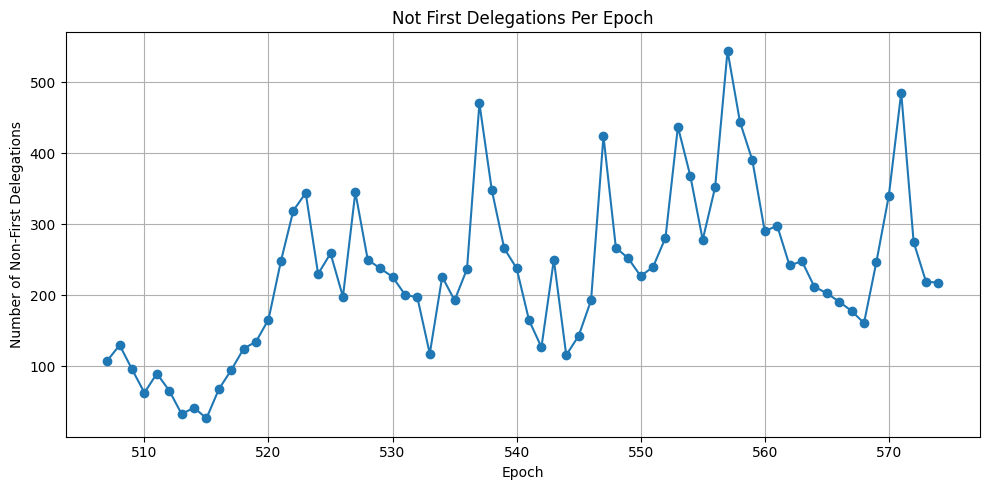

In [25]:
import matplotlib.pyplot as plt

# Step 1: Filter out only non-first delegations
non_first_df = df_no_repeats[df_no_repeats["delegation_index"] > 0]


# Step 2: Count number of non-first delegations per epoch
non_first_counts = (
    non_first_df.groupby("delegation_epoch")
    .size()
    .reset_index(name="num_non_first_delegations")
)

# Step 3: Plot
plt.figure(figsize=(10, 5))
plt.plot(non_first_counts["delegation_epoch"], non_first_counts["num_non_first_delegations"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Non-First Delegations")
plt.title("Not First Delegations Per Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()


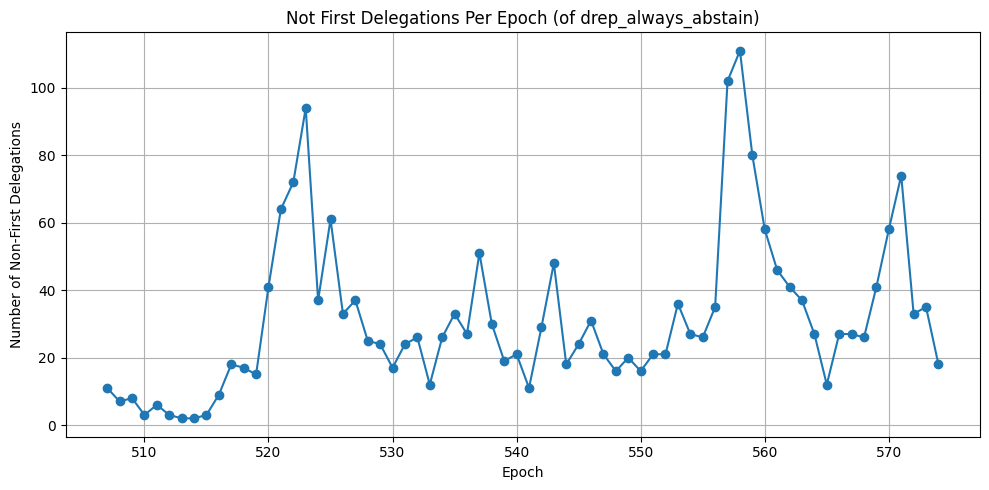

In [26]:
import matplotlib.pyplot as plt

# Step 1: Filter out only non-first delegations
non_first_df = df_no_repeats[df_no_repeats["delegation_index"] > 0]
non_first_df = non_first_df[non_first_df["drep_id"] == "drep_always_abstain"]

# Step 2: Count number of non-first delegations per epoch
non_first_counts = (
    non_first_df.groupby("delegation_epoch")
    .size()
    .reset_index(name="num_non_first_delegations")
)

# Step 3: Plot
plt.figure(figsize=(10, 5))
plt.plot(non_first_counts["delegation_epoch"], non_first_counts["num_non_first_delegations"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Non-First Delegations")
plt.title("Not First Delegations Per Epoch (of drep_always_abstain)")
plt.grid(True)
plt.tight_layout()
plt.show()


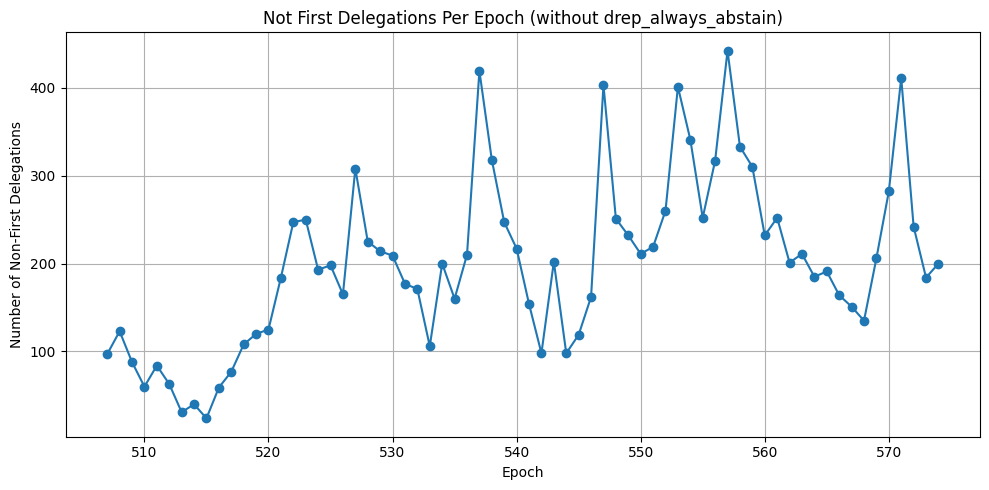

In [28]:
import matplotlib.pyplot as plt

# Step 1: Filter out only non-first delegations
non_first_df = df_no_repeats[df_no_repeats["delegation_index"] > 0]
non_first_df = non_first_df[non_first_df["drep_id"] != "drep_always_abstain"]

# Step 2: Count number of non-first delegations per epoch
non_first_counts = (
    non_first_df.groupby("delegation_epoch")
    .size()
    .reset_index(name="num_non_first_delegations")
)

# Step 3: Plot
plt.figure(figsize=(10, 5))
plt.plot(non_first_counts["delegation_epoch"], non_first_counts["num_non_first_delegations"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Non-First Delegations")
plt.title("Not First Delegations Per Epoch (without drep_always_abstain)")
plt.grid(True)
plt.tight_layout()
plt.show()

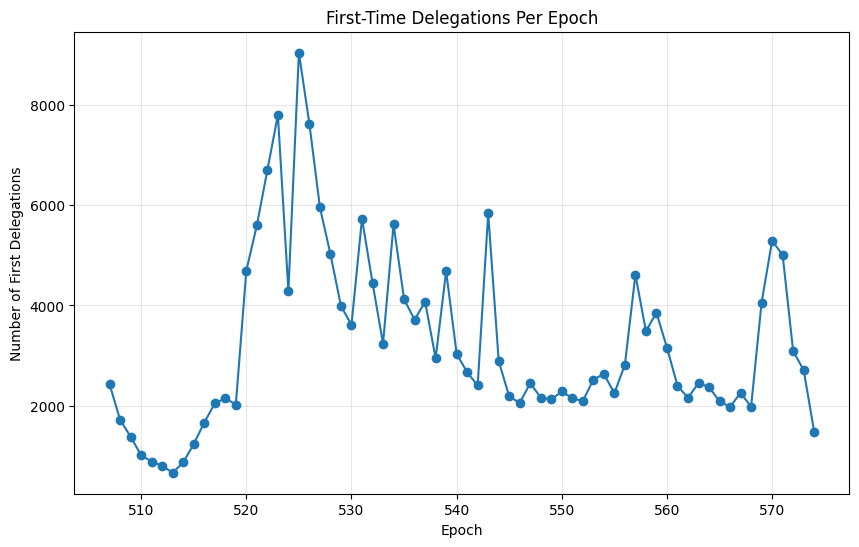

In [29]:
import matplotlib.pyplot as plt

# Step 1: Identify the first delegation per delegator
first_delegations = (
    df_no_repeats.sort_values(["delegator_stake_address", "delegation_timestamp"])
    .groupby("delegator_stake_address")
    .first()
    .reset_index()
)

# Step 2: Count how many first delegations happened per epoch
first_delegations_per_epoch = (
    first_delegations.groupby("delegation_epoch")["delegator_stake_address"]
    .nunique()
    .reset_index(name="num_first_delegations")
)

# Step 3: Plot
plt.figure(figsize=(10,6))
plt.plot(first_delegations_per_epoch["delegation_epoch"], 
         first_delegations_per_epoch["num_first_delegations"], 
         marker="o")

plt.xlabel("Epoch")
plt.ylabel("Number of First Delegations")
plt.title("First-Time Delegations Per Epoch")
plt.grid(alpha=0.3)
plt.show()


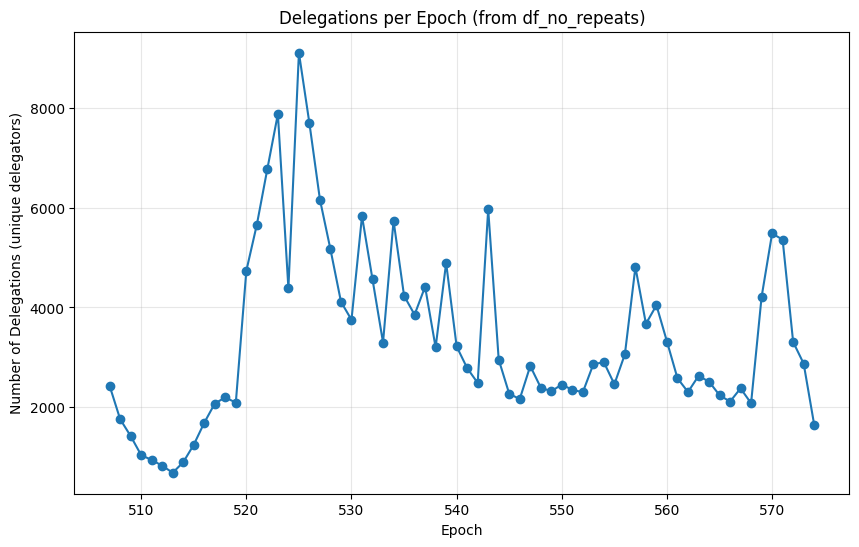

In [34]:
import matplotlib.pyplot as plt

# Count number of delegations per epoch
delegations_per_epoch = (
    df_no_repeats.groupby("delegation_epoch")["delegator_stake_address"]
    .nunique()  # or .count() if you want raw delegation tx count
    .reset_index(name="num_delegations")
)

# Plot
plt.figure(figsize=(10,6))
plt.plot(delegations_per_epoch["delegation_epoch"],
         delegations_per_epoch["num_delegations"],
         marker="o")

plt.xlabel("Epoch")
plt.ylabel("Number of Delegations (unique delegators)")
plt.title("Delegations per Epoch (from df_no_repeats)")
plt.grid(alpha=0.3)
plt.show()


In [36]:
df_no_repeats["delegation_timestamp"]

0        2024-12-07 15:51:32
1        2025-07-03 13:41:32
2        2025-03-05 05:04:44
3        2025-07-04 14:58:52
4        2025-04-07 20:37:54
                 ...        
236479   2025-06-27 20:44:37
236480   2025-03-27 22:07:37
236481   2024-11-30 01:06:26
236482   2024-12-28 19:49:30
236483   2024-12-03 05:21:08
Name: delegation_timestamp, Length: 236484, dtype: datetime64[ns]

In [38]:
!pip install yfinance

  Using cached yfinance-0.2.65-py2.py3-none-any.whl.metadata (5.8 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached frozendict-2.4.6-py312-none-any.whl.metadata (23 kB)
  Using cached peewee-3.18.2-cp312-cp312-macosx_10_9_universal2.whl
  Using cached websockets-15.0.1-cp312-cp312-macosx_10_13_x86_64.whl.metadata (6.8 kB)
  Using cached soupsieve-2.7-py3-none-any.whl.metadata (4.6 kB)
  Using cached cffi-1.17.1-cp312-cp312-macosx_10_9_x86_64.whl.metadata (1.5 kB)
  Using cached pycparser-2.22-py3-none-any.whl.metadata (943 bytes)
Using cached yfinance-0.2.65-py2.py3-none-any.whl (119 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 5.9 MB/s eta 0:00:00a 0:00:01
Using cached cffi-1.17.1-cp312-cp312-macosx_10_9_x86_64.whl (183 kB)
Using cached frozendict-2.4.6-py312-none-any.whl (16 kB)
Using cached soupsieve-2.7-py3-none-any.whl (36 kB)
Using cached websockets-15.0.1-cp312-c

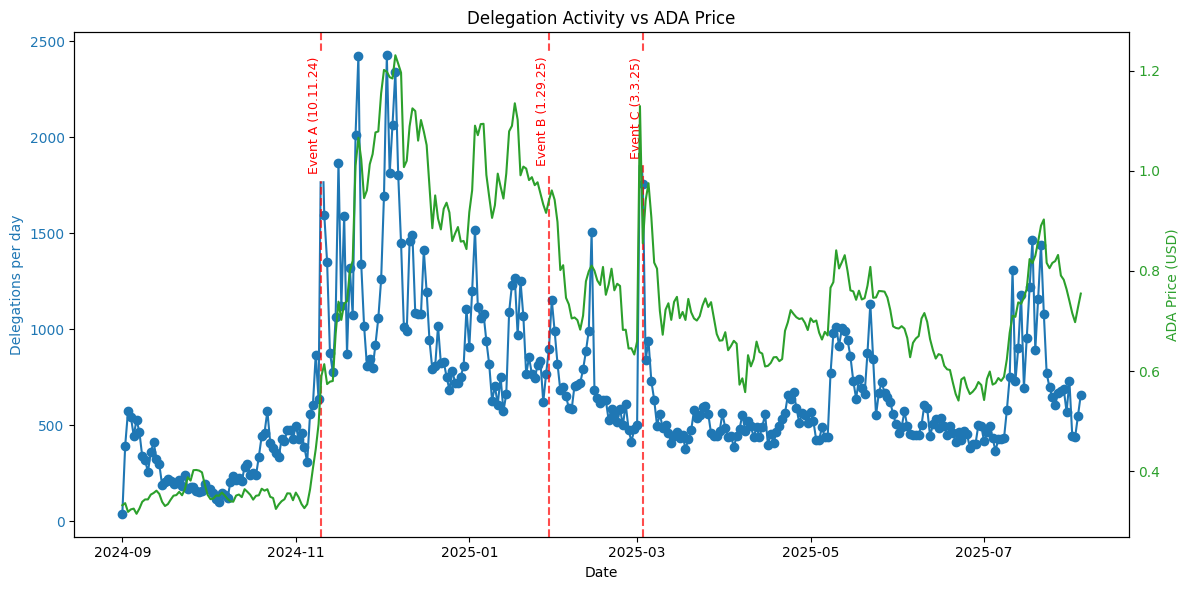

In [47]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt


# Define event dates
event_dates = [dt.datetime(2024, 11, 10), dt.datetime(2025,1,29), dt.datetime(2025, 3, 3)]
event_labels = ["Event A (10.11.24)", "Event B (1.29.25)", "Event C (3.3.25)"]

# --- Step 1: get ADA price data ---
ada = yf.Ticker("ADA-USD")
price_df = ada.history(start=df_no_repeats["delegation_timestamp"].min().date(),
                       end=df_no_repeats["delegation_timestamp"].max().date(),
                       interval="1d")

# Keep only date + close price
price_df = price_df.reset_index()[["Date", "Close"]]
price_df["date"] = pd.to_datetime(price_df["Date"]).dt.tz_localize(None)  # remove UTC
price_df.rename(columns={"Close": "price_usd"}, inplace=True)
price_df.drop(columns="Date", inplace=True)
# --- Step 2: delegations per day ---
delegations_per_day = (
    df_no_repeats.groupby(df_no_repeats["delegation_timestamp"].dt.date)["delegator_stake_address"]
    .nunique()
    .reset_index(name="num_delegations")
)
delegations_per_day.rename(columns={"delegation_timestamp": "date"}, inplace=True)
delegations_per_day["date"] = pd.to_datetime(delegations_per_day["date"])
# --- Step 2.5: add stake registration by day ---




# --- Step 3: merge by date ---
merged = pd.merge(delegations_per_day, price_df, on="date", how="inner")

# --- Step 4: plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Left y-axis: delegations
ax1.plot(merged["date"], merged["num_delegations"], color="tab:blue", marker="o", label="Delegations")
ax1.set_xlabel("Date")
ax1.set_ylabel("Delegations per day", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: ADA price
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["price_usd"], color="tab:green", label="ADA Price")
ax2.set_ylabel("ADA Price (USD)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

# Add vertical event lines
for date, label in zip(event_dates, event_labels):
    ax1.axvline(x=date, color="red", linestyle="--", alpha=0.7)
    ax1.text(date, ax1.get_ylim()[1]*0.95, label, rotation=90, color="red",
             va="top", ha="right", fontsize=9, backgroundcolor="white")

plt.title("Delegation Activity vs ADA Price")
fig.tight_layout()
plt.show()


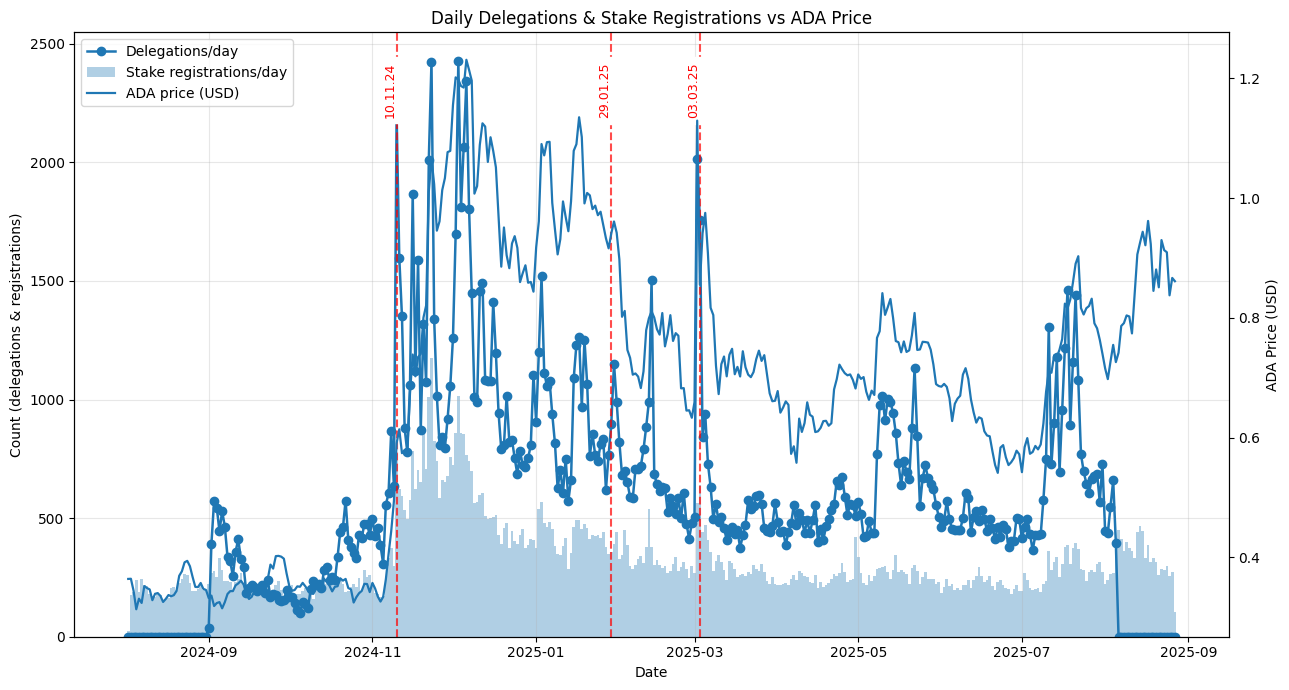

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt

# --- 0) Build delegations/day from your df_no_repeats ---
delegations_per_day = (
    df_no_repeats.groupby(df_no_repeats["delegation_timestamp"].dt.date)["delegator_stake_address"]
    .nunique()
    .reset_index(name="num_delegations")
)
delegations_per_day.rename(columns={"delegation_timestamp": "date"}, inplace=True)
delegations_per_day["date"] = pd.to_datetime(delegations_per_day["date"]).dt.tz_localize(None)

# --- 1) Load stake registrations CSV and aggregate per day ---
# replace the filename with your actual path
reg_csv_path = "./data/data-stake-reg-27.8.25.csv"
regs = pd.read_csv(reg_csv_path)

# parse block_time; make tz-naive to match our other frames
regs["block_time"] = pd.to_datetime(regs["block_time"], utc=True).dt.tz_convert(None)

# Option A (recommended): unique stake keys registered that day
registrations_per_day = (
    regs.groupby(regs["block_time"].dt.date)["addr_id"]
    .nunique()
    .reset_index(name="num_registrations")
)

# if you instead want raw registration certificates per day, use .size() not .nunique():
# registrations_per_day = regs.groupby(regs["block_time"].dt.date).size().reset_index(name="num_registrations")

registrations_per_day.rename(columns={"block_time": "date"}, inplace=True)
registrations_per_day["date"] = pd.to_datetime(registrations_per_day["date"])

# --- 2) Fetch ADA price (daily closes) for the full time span we need ---
start_date = min(delegations_per_day["date"].min(), registrations_per_day["date"].min())
end_date = max(delegations_per_day["date"].max(), registrations_per_day["date"].max())

ada = yf.Ticker("ADA-USD")
price_df = ada.history(start=start_date.date(), end=(end_date + pd.Timedelta(days=1)).date(), interval="1d")
price_df = price_df.reset_index()[["Date", "Close"]]
price_df["date"] = pd.to_datetime(price_df["Date"]).dt.tz_localize(None)  # drop UTC
price_df.rename(columns={"Close": "price_usd"}, inplace=True)
price_df = price_df[["date", "price_usd"]]

# --- 3) Merge all (outer to keep all days), fill NAs with 0 for counts ---
merged = pd.merge(delegations_per_day, registrations_per_day, on="date", how="outer")
merged = pd.merge(merged, price_df, on="date", how="outer")
merged = merged.sort_values("date").reset_index(drop=True)
for col in ["num_delegations", "num_registrations"]:
    merged[col] = merged[col].fillna(0).astype(int)

# --- 4) Plot: delegations (line), registrations (bars), ADA price (right axis) ---
fig, ax1 = plt.subplots(figsize=(13, 7))

# bars for registrations (left axis)
ax1.bar(merged["date"], merged["num_registrations"], width=1.0, alpha=0.35, label="Stake registrations/day")

# line for delegations (left axis)
ax1.plot(merged["date"], merged["num_delegations"], marker="o", linewidth=1.8, label="Delegations/day")

ax1.set_xlabel("Date")
ax1.set_ylabel("Count (delegations & registrations)")
ax1.grid(alpha=0.3)

# right axis: ADA price
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["price_usd"], linewidth=1.6, label="ADA price (USD)")
ax2.set_ylabel("ADA Price (USD)")

# event vertical lines
event_dates = [dt.datetime(2024, 11, 10), dt.datetime(2025, 1, 29), dt.datetime(2025, 3, 3)]
event_labels = ["10.11.24", "29.01.25", "03.03.25"]
for d, lbl in zip(event_dates, event_labels):
    ax1.axvline(x=d, color="red", linestyle="--", alpha=0.7)
    ax1.text(d, ax1.get_ylim()[1] * 0.95, lbl, rotation=90, color="red",
             va="top", ha="right", fontsize=9, backgroundcolor="white")

# unified legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Daily Delegations & Stake Registrations vs ADA Price")
fig.tight_layout()
plt.show()


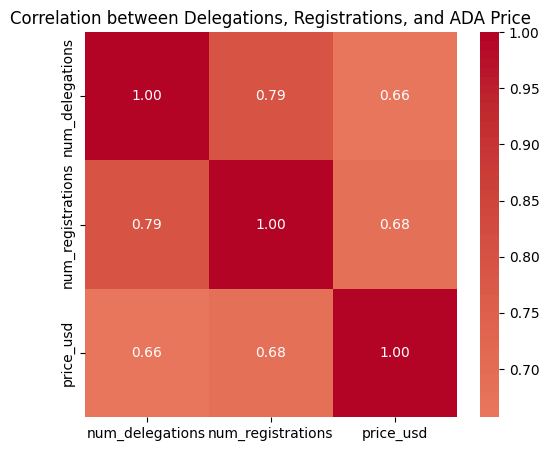

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# take merged daily dataset
corr = merged[["num_delegations", "num_registrations", "price_usd"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation between Delegations, Registrations, and ADA Price")
plt.show()
